# Cloud Height Algorithm Evaluation

First, let's define local data:

In [452]:
import os
from tqdm.notebook import tqdm
from pathlib import Path

DATA_DIR = Path('data/S2-Cloud-Heights')

prediction_files = os.listdir(DATA_DIR / 'predictions')
annotation_files = os.listdir(DATA_DIR / 'annotations')
products = sorted([el for el in annotation_files if el + '.npz' in prediction_files])

In [453]:
products

['S2A_MSIL1C_20180609T094031_N0500_R036_T32NLJ_20230715T110315',
 'S2A_MSIL1C_20250116T113421_N0511_R080_T28SGF_20250116T132959',
 'S2B_MSIL1C_20241101T135659_N0511_R067_T22PDR_20241101T154106',
 'S2B_MSIL1C_20250323T023529_N0511_R089_T51SUU_20250323T041902',
 'S2B_MSIL1C_20250330T104619_N0511_R051_T31UEU_20250330T113536',
 'S2B_MSIL1C_20250410T051649_N0511_R062_T42MYV_20250410T084204',
 'S2C_MSIL1C_20250328T142931_N0511_R096_T22TES_20250328T175847',
 'S2C_MSIL1C_20250408T020711_N0511_R103_T51PWS_20250408T050426']

In [456]:
PRODUCT_ID = products[0]#[1]
YEAR, MONTH, DAY = PRODUCT_ID[11:15],PRODUCT_ID[15:17],PRODUCT_ID[17:19]
MGRS = PRODUCT_ID[38:44]
PRODUCT_PATH = f'/data/s2get/Sentinel-2/MSI/L1C/{YEAR}/{MONTH}/{DAY}/{PRODUCT_ID}.SAFE'
PREDICTION_PATH = DATA_DIR / 'predictions' / f'{PRODUCT_ID}.npz'
ANNOTATION_PATH = DATA_DIR / 'annotations' / f'{PRODUCT_ID}/{MGRS}.geojsonl'

print(f'SELECTED: {PRODUCT_ID}')

SELECTED: S2A_MSIL1C_20180609T094031_N0500_R036_T32NLJ_20230715T110315


and then prepare the data frames:

In [457]:
import geopandas as gpd
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xml.etree.ElementTree as ET
import rasterio
import math
import os
import json
from shapely.geometry import shape, Point
from scipy.interpolate import RegularGridInterpolator

def extract_line_endpoints(geometry):
    """
    Extracts the start and end coordinates of a line geometry,
    handling both LineString and MultiLineString.
    """
    if geometry.geom_type == 'LineString':
        start_coord = geometry.coords[0]
        end_coord = geometry.coords[-1]
    elif geometry.geom_type == 'MultiLineString':
        # Get the start of the first line and the end of the last line
        start_coord = geometry.geoms[0].coords[0]
        end_coord = geometry.geoms[-1].coords[-1]
    else:
        start_coord = None
        end_coord = None  # Or raise an exception, depending on how you want to handle other types
    return start_coord, end_coord


def extract_xy_from_coord(coord):
    """Extracts x and y from a coordinate tuple."""
    if coord:
        return coord[0], coord[1]
    else:
        return None, None


def process_geodataframe(gdf):
    """
    Processes a GeoDataFrame to extract start and end coordinates.
    """
    gdf['start_coord'], gdf['end_coord'] = zip(*gdf['geometry'].apply(extract_line_endpoints))
    gdf['start_x'], gdf['start_y'] = zip(*gdf['start_coord'].apply(extract_xy_from_coord))
    gdf['end_x'], gdf['end_y'] = zip(*gdf['end_coord'].apply(extract_xy_from_coord))
    return gdf

def geojsonl_to_geopandas(geojsonl_filepath):
    """
    Reads a GeoJSONL file and converts it into a geopandas GeoDataFrame.

    Args:
        geojsonl_filepath (str): Path to the GeoJSONL file.

    Returns:
        geopandas.GeoDataFrame: A GeoDataFrame containing the GeoJSON features.
    """

    features = []
    with open(geojsonl_filepath, 'r') as f:
        for line in f:
            try:
                feature = json.loads(line)
                features.append(feature)
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON: {e}")

    # Extract geometry and properties
    geometries = [shape(feature['geometry']) for feature in features]
    properties = [feature['properties'] for feature in features]

    # Create a GeoDataFrame
    gdf = gpd.GeoDataFrame(properties, geometry=geometries)

    return gdf

def _find_tile_metadata_path(safe_path):
    """Finds the MTD_TL.xml file within a Sentinel-2 SAFE directory."""
    for root, dirs, files in os.walk(safe_path):
        if "GRANULE" in dirs:
            granule_dir = os.path.join(root, "GRANULE")
            for granule_root, _, granule_files in os.walk(granule_dir):
                if "MTD_TL.xml" in granule_files:
                    return os.path.join(granule_root, "MTD_TL.xml")
    raise FileNotFoundError("Sentinel-2 MTD_TL.xml file not found.")

def _extract_sun_angle_grid(root, angle_type, ns):
    """Extracts a sun angle grid (Zenith or Azimuth) from the XML."""

    angle_element = root.find(f".//Tile_Angles/Sun_Angles_Grid/{angle_type}", namespaces=ns)
    if angle_element is None:
        raise ValueError(f"Sun {angle_type} angles not found in MTD_TL.xml.")

    col_step_element = angle_element.find("COL_STEP", namespaces=ns)
    row_step_element = angle_element.find("ROW_STEP", namespaces=ns)
    values_list_elements = angle_element.findall("Values_List/VALUES", namespaces=ns)

    if col_step_element is None or row_step_element is None or not values_list_elements:
        raise ValueError(f"Incomplete sun {angle_type} angle grid information in MTD_TL.xml.")

    col_step = float(col_step_element.text)
    row_step = float(row_step_element.text)
    grid_values = []
    for values_element in values_list_elements:
        grid_values.append(list(map(float, values_element.text.split())))

    return {
        "col_step": col_step,
        "row_step": row_step,
        "values": np.array(grid_values)
    }

def _interpolate_sun_angles(angle_grid, x, y, transform):
    """Interpolates sun angles from the grid to given coordinates."""

    ulx, xres, _, uly, _, yres = transform
    col_coords = np.arange(0, angle_grid["values"].shape[1]) * angle_grid["col_step"] + ulx
    row_coords = uly - np.arange(0, angle_grid["values"].shape[0]) * angle_grid["row_step"]

    interp_func = RegularGridInterpolator((row_coords, col_coords), angle_grid["values"], bounds_error=False,
                                        fill_value=None)
    return interp_func((y, x))

def _get_metadata(metadata_path):
    """
    Extracts relevant metadata from the MTD_TL.xml file.

    Args:
        metadata_path (str): Path to the MTD_TL.xml file.

    Returns:
        dict: A dictionary containing CRS, transform, and sun angle grids.
    """
    tree = ET.parse(metadata_path)
    root = tree.getroot()
    ns = {'n1': 'https://psd-15.sentinel2.eo.esa.int/PSD/S2_PDI_Level-1C_Tile_Metadata.xsd'}

    # Extract CRS
    horizontal_cs_code_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/HORIZONTAL_CS_CODE",
                                            namespaces=ns)
    if horizontal_cs_code_element is not None:
        utm_crs = horizontal_cs_code_element.text
    else:
        raise ValueError("UTM CRS (HORIZONTAL_CS_CODE) not found in MTD_TL.xml.")

    # Extract transform (geotransform) parameters
    # Extract transform (geotransform) parameters
    ulx_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/ULX", namespaces=ns)
    uly_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/ULY", namespaces=ns)
    xdim_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/XDIM", namespaces=ns)
    ydim_element = root.find(".//n1:Geometric_Info/Tile_Geocoding/Geoposition[@resolution='10']/YDIM", namespaces=ns)

    if ulx_element is not None and uly_element is not None and xdim_element is not None and ydim_element is not None:
        ulx = float(ulx_element.text)
        uly = float(uly_element.text)
        xdim = float(xdim_element.text)
        ydim = float(ydim_element.text)
        transform = (ulx, xdim, 0, uly, 0, ydim)  # GDAL geotransform
    else:
        raise ValueError("Geotransform information not found in MTD_TL.xml.")

    # Extract sun angle grids
    sun_zenith_grid = _extract_sun_angle_grid(root, "Zenith", ns)
    sun_azimuth_grid = _extract_sun_angle_grid(root, "Azimuth", ns)

    return {
        "utm_crs": utm_crs,
        "transform": transform,
        "sun_zenith_grid": sun_zenith_grid,
        "sun_azimuth_grid": sun_azimuth_grid
    }

def _load_prediction_data(npz_output_path, transform, crs):
    """
    Loads prediction data from an .npz file and transforms coordinates to a GeoDataFrame.

    Args:
        npz_output_path (str): Path to the .npz file.
        transform (tuple): GDAL geotransform tuple.
        crs (str, optional): The CRS to assign to the GeoDataFrame. Defaults to "EPSG:32742" (UTM zone).

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame with 'geometry' (Point), 'utm_x', 'utm_y', and 'height' columns.
    """
    npz_data = np.load(npz_output_path)
    heights = npz_data['heights']
    coords = npz_data['coords']/10

    ulx, xres, x_rotation, uly, y_rotation, yres = transform  # Corrected unpacking
    utm_x = ulx + coords[:, 0] * xres
    utm_y = uly + coords[:, 1] * yres

    geometry = [Point(x, y) for x, y in zip(utm_x, utm_y)]

    prediction_df = pd.DataFrame({
        'utm_x': utm_x,
        'utm_y': utm_y,
        'height': heights
    })

    prediction_gdf = gpd.GeoDataFrame(prediction_df, geometry=geometry, crs=crs)

    return prediction_gdf


def _load_ground_truth_data(geojsonl_annotations_path, utm_crs):
    """
    Loads ground truth data from a GeoJSONL file and reprojects it to the specified UTM CRS.

    Args:
        geojsonl_annotations_path (str): Path to the GeoJSONL file.
        utm_crs (str): The target UTM CRS (e.g., "EPSG:32742").

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame with the ground truth data in the specified UTM CRS.
    """
    gdf = geojsonl_to_geopandas(geojsonl_annotations_path).explode() # explode converts multilinestring to linestring

    # 1. Check if gdf already has a CRS
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")  # ASSUME WGS 84 if no CRS is present
        
    gdf = gdf.to_crs(utm_crs)
    return gdf

In [458]:
# Stage I: Data Prep
# 0. Read all necessary information from the scene metadata
metadata_path = _find_tile_metadata_path(PRODUCT_PATH)
metadata = _get_metadata(metadata_path)

# 1. Read the output of the algorithm and map the points to the UTM of the scene
prediction_df = _load_prediction_data(PREDICTION_PATH, metadata['transform'], metadata['utm_crs'])

# 2. Read the geometry of the ground truth file (geojson) and map it to the UTM of the scene in gt_df dataframe
gt_df = _load_ground_truth_data(ANNOTATION_PATH, metadata['utm_crs'])
gt_df = process_geodataframe(gt_df)

gt_df.head()

ValueError: UTM CRS (HORIZONTAL_CS_CODE) not found in MTD_TL.xml.

The script also read sun angle grids from metadata:

Text(0.5, 1.0, 'Sun Azimuth')

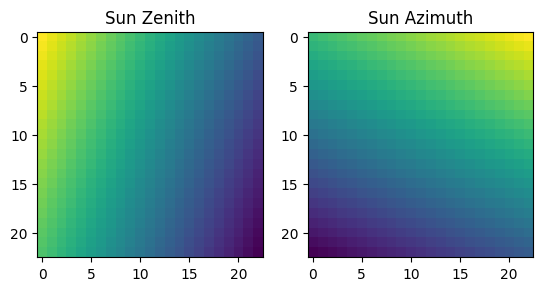

In [459]:
import matplotlib.pyplot as plt

plt.subplot(121)
plt.imshow(metadata['sun_zenith_grid']['values'])
plt.title('Sun Zenith')
plt.subplot(122)
plt.imshow(metadata['sun_azimuth_grid']['values'])
plt.title('Sun Azimuth')

In [460]:
def _determine_cloud_top(gdf):
    """Determines cloud top coordinates using sun azimuth."""
    cloud_top_x = []
    cloud_top_y = []

    for _, row in gdf.iterrows():
        start_x, start_y, end_x, end_y = row['start_x'], row['start_y'], row['end_x'], row['end_y']

        # Calculate line direction
        line_azimuth = math.degrees(math.atan2(end_y - start_y, end_x - start_x))

        # Normalize azimuth angles to 0-360 range
        sun_azimuth = row['sun_azimuth']
        sun_azimuth_norm = (sun_azimuth + 360) % 360
        line_azimuth_norm = (line_azimuth + 360) % 360

        # Determine if line direction is opposite to sun azimuth
        angle_diff = abs(sun_azimuth_norm - line_azimuth_norm)
        if angle_diff > 180:
            angle_diff = 360 - angle_diff

        if False:#angle_diff > 90:  # Adjust tolerance as needed
            cloud_top_x.append(end_x)
            cloud_top_y.append(end_y)
        else:
            cloud_top_x.append(start_x)
            cloud_top_y.append(start_y)

    return cloud_top_x, cloud_top_y

def _calculate_ground_truth_heights(gdf, scene_metadata):
    """
    Calculates cloud heights for the ground truth lines based on sun angles.

    Args:
        gdf (gpd.GeoDataFrame): GeoDataFrame containing ground truth line geometries.
        sun_zenith_grid (dict): Dictionary containing sun zenith angle grid information.
        transform (tuple): GDAL geotransform tuple.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame with an added 'height' column.
    """
    sun_zenith_grid = metadata['sun_zenith_grid']
    sun_azimuth_grid = metadata['sun_azimuth_grid']
    transform = metadata['transform']
    

    gdf['length'] = gdf['geometry'].length

    gdf['sun_zenith'] = _interpolate_sun_angles(sun_zenith_grid, gdf['start_x'], gdf['start_y'], transform)
    gdf['sun_elevation'] = 90 - gdf['sun_zenith']
    gdf['sun_azimuth'] = _interpolate_sun_angles(sun_azimuth_grid, gdf['start_x'], gdf['start_y'], transform)
    gdf['height'] = gdf['length'] * np.tan(np.radians(gdf['sun_elevation']))

    # Determine cloud top using sun azimuth
    gdf['cloud_top_x'], gdf['cloud_top_y'] = _determine_cloud_top(gdf)

    return gdf

In [461]:
# 3. Create another column ('height') to gt_df that estimates height based on each line and sun angle information
gt_df = _calculate_ground_truth_heights(gt_df, metadata)

gt_df

,,id,Lines,geometry,start_coord,end_coord,start_x,start_y,end_x,end_y,length,sun_zenith,sun_elevation,sun_azimuth,height,cloud_top_x,cloud_top_y
0,0,1.0,None,"LINESTRING (576176.503 1648223.220, 575910.763...","(576176.5026868635, 1648223.220479397)","(575910.7626801883, 1648337.9663660114)",576176.502687,1.648223e+06,575910.762680,1.648338e+06,289.455298,21.764261,68.235739,108.318371,725.001086,576176.502687,1.648223e+06
1,0,2.0,None,"LINESTRING (573762.174 1648360.620, 573512.294...","(573762.1735418336, 1648360.6204182857)","(573512.2935363275, 1648446.6821696302)",573762.173542,1.648361e+06,573512.293536,1.648447e+06,264.285153,21.785102,68.214898,108.298865,661.258616,573762.173542,1.648361e+06
2,0,3.0,None,"LINESTRING (584166.131 1654821.464, 583826.394...","(584166.1310360791, 1654821.463661042)","(583826.3942685955, 1654954.3430712451)",584166.131036,1.654821e+06,583826.394269,1.654954e+06,364.798587,21.719210,68.280790,108.530804,915.804458,584166.131036,1.654821e+06
3,0,4.0,None,"LINESTRING (587664.557 1648815.098, 587371.634...","(587664.5571522395, 1648815.0976970645)","(587371.6344650406, 1648929.8517869317)",587664.557152,1.648815e+06,587371.634465,1.648930e+06,314.598477,21.669302,68.330698,108.437975,791.785640,587664.557152,1.648815e+06
4,0,5.0,None,"LINESTRING (592547.566 1644866.718, 592287.868...","(592547.5662925845, 1644866.7183006075)","(592287.867581854, 1644955.792849195)",592547.566293,1.644867e+06,592287.867582,1.644956e+06,274.549987,21.614744,68.385256,108.400496,692.913105,592547.566293,1.644867e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,0,NaN,None,"LINESTRING (588286.829 1619753.725, 587956.163...","(588286.828917524, 1619753.7245479156)","(587956.1627895789, 1619876.0176910474)",588286.828918,1.619754e+06,587956.162790,1.619876e+06,352.555954,21.566880,68.433120,107.830692,891.960772,588286.828918,1.619754e+06
98,0,NaN,None,"LINESTRING (585402.925 1619590.647, 585100.946...","(585402.9248628496, 1619590.6473123375)","(585100.9456513535, 1619708.4221450426)",585402.924863,1.619591e+06,585100.945651,1.619708e+06,324.133237,21.590739,68.409261,107.801280,819.053862,585402.924863,1.619591e+06
99,0,NaN,None,"LINESTRING (597690.472 1609993.742, 597406.610...","(597690.471712878, 1609993.7417232404)","(597406.6104801553, 1610090.3744729713)",597690.471713,1.609994e+06,597406.610480,1.610090e+06,299.858446,21.455118,68.544882,107.708946,762.987193,597690.471713,1.609994e+06
100,0,NaN,None,"LINESTRING (595202.150 1610516.171, 594930.371...","(595202.1504226832, 1610516.1713011852)","(594930.3711505234, 1610618.8406738641)",595202.150423,1.610516e+06,594930.371151,1.610619e+06,290.525339,21.477892,68.522108,107.697230,738.376942,595202.150423,1.610516e+06


In [462]:
prediction_df

,utm_x,utm_y,height,geometry
0,500648.62500,1698985.375,0.0,POINT (500648.625 1698985.375)
1,500345.62500,1697618.625,150.0,POINT (500345.625 1697618.625)
2,500891.93750,1699180.750,0.0,POINT (500891.938 1699180.750)
3,500805.34375,1698790.125,50.0,POINT (500805.344 1698790.125)
4,500962.06250,1698594.875,150.0,POINT (500962.062 1698594.875)
...,...,...,...,...
257014,609164.12500,1591249.250,0.0,POINT (609164.125 1591249.250)
257015,609120.81250,1591054.000,0.0,POINT (609120.812 1591054.000)
257016,609077.50000,1590858.750,0.0,POINT (609077.500 1590858.750)
257017,609034.25000,1590663.500,0.0,POINT (609034.250 1590663.500)


[]

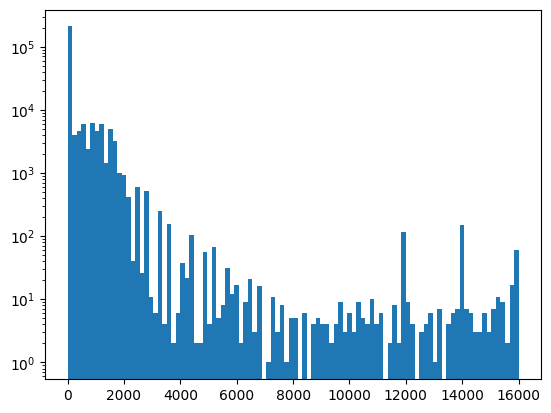

In [463]:
plt.hist(prediction_df.height,bins=100)
plt.semilogy()

<Axes: >

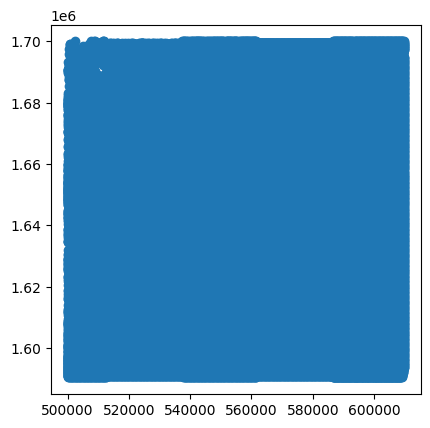

In [464]:
prediction_df.plot()

<Axes: >

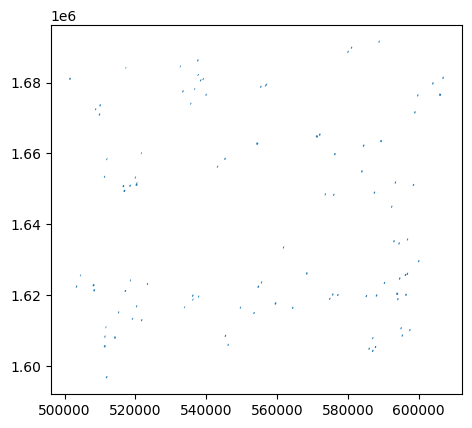

In [465]:
gt_df.plot()

## Evaluation:
Finally, we can find the closest points in the two data frames and apply performance metrics based on matched data points:

In [466]:
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Point
from tqdm import tqdm

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Point
from tqdm import tqdm

def _match_predictions_to_ground_truth(prediction_df, gt_df, distance_threshold=200):
    """
    Matches predicted cloud heights to the nearest ground truth cloud top locations.

    Args:
        prediction_df (gpd.GeoDataFrame): GeoDataFrame containing predicted cloud heights and coordinates (geometry column).
        gt_df (gpd.GeoDataFrame): GeoDataFrame containing ground truth annotations with 'cloud_top_x', 'cloud_top_y', and 'height'.

    Returns:
        gpd.GeoDataFrame: GeoDataFrame with matched predicted and ground truth heights,
                        'geometry' (prediction location), 'gt_coords' (ground truth location as float tuples), and 'distance' columns.
    """

    predicted_heights = []
    ground_truth_heights = []
    prediction_geometries = []  # Store prediction geometries
    gt_coords_list = []  # Store ground truth coordinates as tuples
    distances_list = []

    # Create GeoSeries of cloud top points for distance calculations
    gt_cloud_top_points = gpd.GeoSeries(
        [Point(x, y) for x, y in zip(gt_df['cloud_top_x'], gt_df['cloud_top_y'])],
        crs=gt_df.crs  # Ensure the same CRS as prediction_df
    )

    for i, gt_point in enumerate(tqdm(gt_cloud_top_points, total=len(gt_cloud_top_points))):
        # Calculate distances to predicted points
        distances = prediction_df['geometry'].distance(gt_point)
        nearest_index = np.argmin(distances)
        distance_value = distances.iloc[nearest_index] #get the distance

        if distance_value < distance_threshold:
            # Append predicted and ground truth heights
            predicted_heights.append(prediction_df['height'].iloc[nearest_index])
            ground_truth_heights.append(gt_df['height'].iloc[i])

            # Append the geometries
            prediction_geometries.append(prediction_df['geometry'].iloc[nearest_index])
            gt_coords_list.append((gt_point.x, gt_point.y))  # Save as float tuple
            distances_list.append(distance_value)

    # Create the output GeoDataFrame
    matched_data = pd.DataFrame({
        'predicted_height': predicted_heights,
        'ground_truth_height': ground_truth_heights,
        'geometry': prediction_geometries,  # Prediction geometry
        'gt_coords': gt_coords_list,  # Ground truth coordinates as tuples
        'distance': distances_list
    })
    matched_gdf = gpd.GeoDataFrame(matched_data, geometry='geometry', crs=gt_df.crs)  # Ensure geometry is correctly set

    return matched_gdf

def _compute_performance_metrics(matched_data):
    """
    Computes regression performance metrics.

    Args:
        matched_data (pd.DataFrame): DataFrame with matched predicted and ground truth heights.

    Returns:
        dict: A dictionary containing regression performance metrics.
    """

    mse = mean_squared_error(matched_data['ground_truth_height'], matched_data['predicted_height'])
    mae = mean_absolute_error(matched_data['ground_truth_height'], matched_data['predicted_height'])
    r2 = r2_score(matched_data['ground_truth_height'], matched_data['predicted_height'])

    return {
        'mse': mse,
        'mae': mae,
        'r2': r2,
        'ground_truth_heights': matched_data['ground_truth_height'].tolist(),
        'predicted_heights': matched_data['predicted_height'].tolist()
    }


def validate_cloud_height(npz_output_path, geojsonl_annotations_path, sentinel2_safe_path):
    """
    Validates cloud height algorithm output against GeoJSONL annotations.

    Args:
        npz_output_path (str): Path to the algorithm output .npz file (coordinates, height).
        geojsonl_annotations_path (str): Path to the QGIS annotations GeoJSONL file.
        sentinel2_safe_path (str): Path to the Sentinel-2 SAFE directory.

    Returns:
        dict: A dictionary containing regression performance metrics.
    """

    # Stage I: Data Prep
    # 0. Read all necessary information from the scene metadata
    metadata_path = _find_tile_metadata_path(sentinel2_safe_path)
    metadata = _get_metadata(metadata_path)

    # 1. Read the output of the algorithm and map the points to the UTM of the scene
    prediction_df = _load_prediction_data(npz_output_path, metadata['transform'])

    # 2. Read the geometry of the ground truth file (geojson) and map it to the UTM of the scene in gt_df dataframe
    gt_df = _load_ground_truth_data(geojsonl_annotations_path, metadata['utm_crs'])

    # 3. Create another column ('height') to gt_df that estimates height based on each line and sun angle information
    gt_df = _calculate_ground_truth_heights(gt_df, metadata['sun_zenith_grid'], metadata['transform'])

    # Stage II: Validation
    # 1. Match. points from gt_df to the closest points in prediction_df
    matched_data = _match_predictions_to_ground_truth(prediction_df, gt_df)

    # 2. Compute the performance metrics on existing data
    results = _compute_performance_metrics(matched_data)

    return results

In [467]:
# Stage II: Validation
# 1. Match. points from gt_df to the closest points in prediction_df
matched_data = _match_predictions_to_ground_truth(prediction_df, gt_df)
matched_data.to_parquet(DATA_DIR / f'evaluation/{PRODUCT_ID}.parquet')

# filter out 0s
matched_data = matched_data[matched_data.predicted_height > 0]

# 2. Compute the performance metrics on existing data
results = _compute_performance_metrics(matched_data)

100%|█████████████████████████████████████████| 102/102 [00:05<00:00, 19.14it/s]


/tmp/ipykernel_2753450/3816632915.py:50: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line", color='red')


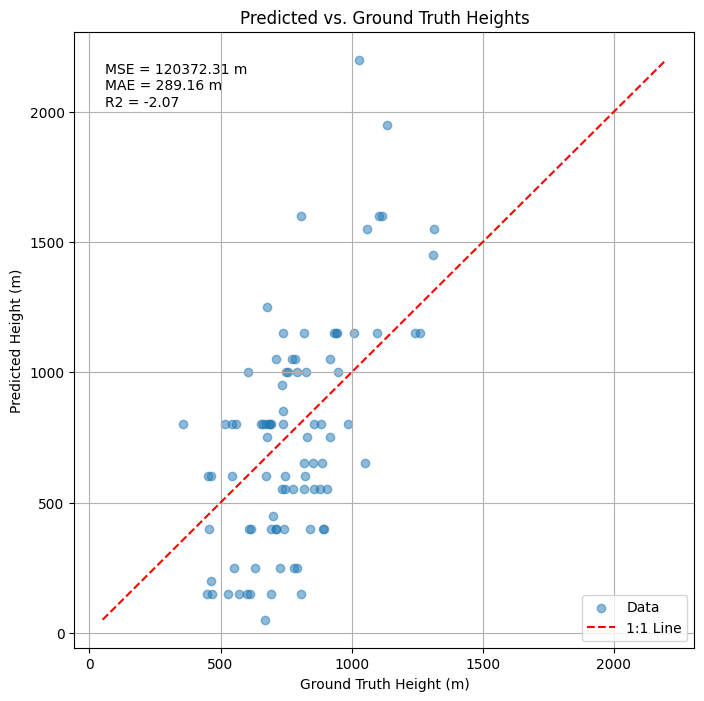

In [513]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_correlation_scatter_with_metrics(matched_data, maxval=None, loglog=False, title="Predicted vs. Ground Truth Heights"):
    """
    Generates a correlation scatter plot of predicted vs. ground truth heights
    and displays MSE, MAE, and R2 on the plot. Handles single DataFrame or a list of DataFrames.

    Args:
        matched_data (pd.DataFrame or list of pd.DataFrame): DataFrame(s) with 'predicted_height' and 'ground_truth_height' columns.
        maxval (float, optional): Maximum value for the plot axes. Defaults to None.
        loglog (bool, optional): Whether to use a log-log scale. Defaults to False.
        title (str, optional): Title of the plot. Defaults to "Predicted vs. Ground Truth Heights".

    Returns:
        None: Displays the plot.
    """

    plt.figure(figsize=(8, 8))
    plt.xlabel("Ground Truth Height (m)")
    plt.ylabel("Predicted Height (m)")
    plt.title(title)
    plt.grid(True)

    all_data = pd.DataFrame()

    if isinstance(matched_data, list):
        colors = plt.cm.viridis(np.linspace(0, 1, len(matched_data)))
        for i, df in enumerate(matched_data):
            if isinstance(df, pd.DataFrame) and 'ground_truth_height' in df.columns and 'predicted_height' in df.columns:
                plt.scatter(df['ground_truth_height'], df['predicted_height'], alpha=0.5, label=f"Run {i+1}", color=colors[i])
                all_data = pd.concat([all_data, df], ignore_index=True)
        plt.legend()
    elif isinstance(matched_data, pd.DataFrame) and 'ground_truth_height' in matched_data.columns and 'predicted_height' in matched_data.columns:
        plt.scatter(matched_data['ground_truth_height'], matched_data['predicted_height'], alpha=0.5, label="Data")
        all_data = matched_data
        plt.legend()
    else:
        print("Warning: Input matched_data is not a DataFrame or a list of DataFrames.")
        plt.show()
        return

    if not all_data.empty:
        mse = mean_squared_error(all_data['ground_truth_height'], all_data['predicted_height'])
        mae = mean_absolute_error(all_data['ground_truth_height'], all_data['predicted_height'])
        r2 = r2_score(all_data['ground_truth_height'], all_data['predicted_height'])

        min_val = min(all_data['ground_truth_height'].min(), all_data['predicted_height'].min())
        max_val = max(all_data['ground_truth_height'].max(), all_data['predicted_height'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line", color='red')
        plt.legend(loc='lower right')

        metrics_text = f"MSE = {mse:.2f} m\nMAE = {mae:.2f} m\nR2 = {r2:.2f}"
        plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, verticalalignment='top')

        if maxval is not None and not loglog:
            plt.axis([0, maxval, 0, maxval])

        if loglog:
            plt.loglog()

        plt.show()
    else:
        print("Warning: No valid data to plot.")

plot_correlation_scatter_with_metrics(matched_data)

In [509]:
matched_data

,predicted_height,ground_truth_height,geometry,gt_coords,distance
0,250.0,725.001086,POINT (576193.750 1648218.000),"(576176.5026868635, 1648223.220479397)",18.020078
1,800.0,661.258616,POINT (573804.625 1648266.875),"(573762.1735418336, 1648360.6204182857)",102.909328
2,750.0,915.804458,POINT (584265.562 1654856.875),"(584166.1310360791, 1654821.463661042)",105.548941
3,250.0,791.785640,POINT (587723.625 1648803.875),"(587664.5571522395, 1648815.0976970645)",60.124534
4,400.0,692.913105,POINT (592657.875 1644898.625),"(592547.5662925845, 1644866.7183006075)",114.830520
...,...,...,...,...,...
94,400.0,712.466371,POINT (575100.562 1618929.125),"(575046.5291159991, 1618841.745591738)",102.736398
95,400.0,891.960772,POINT (588273.750 1619710.250),"(588286.828917524, 1619753.7245479156)",45.399278
96,650.0,819.053862,POINT (585430.438 1619515.000),"(585402.9248628496, 1619590.6473123375)",80.495100
98,800.0,738.376942,POINT (595225.375 1610470.500),"(595202.1504226832, 1610516.1713011852)",51.237181


In [510]:
val_df=[]
for p_id in products:
    val_df.append(gpd.read_parquet(DATA_DIR / f'evaluation/{p_id}.parquet').to_crs(4326))
    val_df[-1]= val_df[-1][val_df[-1].predicted_height > 0]

#val_df = pd.concat(val_df)
# filter out 0s
#val_df= val_df[val_df.predicted_height > 0]


/tmp/ipykernel_2753450/3816632915.py:50: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="1:1 Line", color='red')


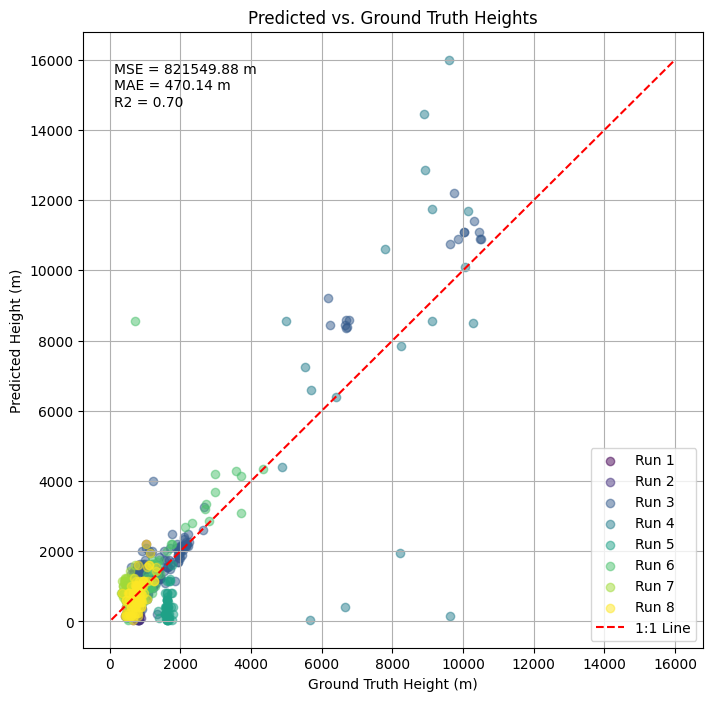

In [514]:
plot_correlation_scatter_with_metrics(val_df)#, loglog=True)